# 15 – Vergleichsgrafik: Prognose vs. Realität (8 / 24 / 48 / 72 h)

Ein Vorhersage-Ursprung (Station **Aotizhongxin**, Beginn Testjahr). Für die nächsten 72 h werden die realen Werte drei Prognosen gegenübergestellt:
- **Seasonal Naive** – letzte 24 beobachteten Stunden, wiederholt (Baseline).
- **Prophet (bester Ansatz)** – behandelt + Feiertag + Regressoren (Perfect Prognosis).
- **TFT (bester Ansatz)** – behandelt + FT + Regressoren (Perfect Prognosis).

Vier Panels zeigen den jeweils ersten Ausschnitt (8/24/48/72 h). Kernel **Python (tft)**, *Run All*.

> Prophet wird direkt versucht; falls Prophet im `tft`-Kernel fehlt, liest das Notebook `../data/plot_prophet.csv` (vorher **15b** im Prophet-Kernel ausführen).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, gc
import matplotlib.pyplot as plt
import torch, holidays
from pathlib import Path
from neuralforecast import NeuralForecast
from neuralforecast.models import TFT
from neuralforecast.losses.pytorch import MAE as NF_MAE

torch.set_float32_matmul_precision('high')

STATION      = 'Aotizhongxin'
H            = 72
STARTOFFSET  = 0            # Ursprung verschieben, um ein anderes Fenster zu zeigen (in Stunden)
INPUT_SIZE   = 168
MAX_STEPS    = 1000
HIDDEN_SIZE  = 64
WINDOWS_BATCH= 128
DATA_DIR     = Path('../data/prepared')
GRAF_DIR     = Path('../grafiken'); GRAF_DIR.mkdir(exist_ok=True)
REGRESSOREN  = ['TEMP','DEWP','PRES','WSPM','RAIN','wd_sin','wd_cos']
print('GPU:', torch.cuda.is_available())

GPU: True


In [2]:
def lade(v):
    tr = pd.read_csv(DATA_DIR/v/f'prophet_train_{STATION}.csv', parse_dates=['ds'])
    te = pd.read_csv(DATA_DIR/v/f'prophet_test_{STATION}.csv',  parse_dates=['ds'])
    return tr, te
def reg(df, cols):
    d = df.copy(); d['ds']=pd.to_datetime(d['ds']); d=d.set_index('ds').sort_index()
    d = d.reindex(pd.date_range(d.index.min(), d.index.max(), freq='h'))
    for cc in cols: d[cc]=d[cc].interpolate(limit_direction='both')
    d.index.name='ds'; return d.reset_index()
def add_time(d):
    d=d.copy()
    d['hour_sin']=np.sin(2*np.pi*d['ds'].dt.hour/24); d['hour_cos']=np.cos(2*np.pi*d['ds'].dt.hour/24)
    d['day_sin']=np.sin(2*np.pi*d['ds'].dt.dayofyear/365.25); d['day_cos']=np.cos(2*np.pi*d['ds'].dt.dayofyear/365.25)
    return d
def add_feiertag(d):
    cn=holidays.country_holidays('CN', years=range(2013,2018))
    d=d.copy(); d['feiertag']=d['ds'].dt.date.astype('O').map(lambda t:1 if t in cn else 0); return d
def mae(a,b): a=np.asarray(a,float); b=np.asarray(b,float); return float(np.mean(np.abs(a-b)))

tr, te = lade('behandelt')
train = reg(tr, ['y']+REGRESSOREN)
test  = reg(te, ['y']+REGRESSOREN)
fenster = test.iloc[STARTOFFSET:STARTOFFSET+H].reset_index(drop=True)
ds_zukunft = fenster['ds']
y_real  = fenster['y'].values
# Seasonal Naive: letzte 24 beobachtete Stunden vor dem Ursprung, 3x wiederholt
vor_ursprung = pd.concat([train, test.iloc[:STARTOFFSET]], ignore_index=True)
letzte24 = vor_ursprung['y'].values[-24:]
y_naive = np.tile(letzte24, int(np.ceil(H/24)))[:H]
print('Ursprung:', ds_zukunft.iloc[0], '| reale Werte:', len(y_real))

Ursprung: 2016-03-01 00:00:00 | reale Werte: 72


In [3]:
# --- TFT (bester Ansatz): behandelt + FT + Regressoren, Perfect Prognosis ---
futr_exog = REGRESSOREN + ['hour_sin','hour_cos','day_sin','day_cos','feiertag']
df_train = add_feiertag(add_time(reg(pd.concat([tr, test.iloc[:STARTOFFSET]], ignore_index=True), ['y']+REGRESSOREN)))
df_train.insert(0,'unique_id',STATION)
df_train = df_train[['unique_id','ds','y']+futr_exog]
fut = add_feiertag(add_time(fenster.copy())); fut.insert(0,'unique_id',STATION)
fut = fut[['unique_id','ds']+futr_exog]

model = TFT(h=H, input_size=INPUT_SIZE, futr_exog_list=futr_exog,
            loss=NF_MAE(), max_steps=MAX_STEPS, batch_size=32,
            hidden_size=HIDDEN_SIZE, windows_batch_size=WINDOWS_BATCH,
            inference_windows_batch_size=WINDOWS_BATCH,
            accelerator='gpu', devices=1, precision='16-mixed', enable_progress_bar=True)
nf = NeuralForecast(models=[model], freq='h')
nf.fit(df=df_train)
pred = nf.predict(futr_df=fut)
y_tft = np.clip(pred['TFT'].values[:H], 0, None)
del model, nf; gc.collect(); torch.cuda.empty_cache()
print('TFT fertig:', len(y_tft))

Seed set to 1
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                     | Params
---------------------------------------------------------------------
0 | loss                    | MAE                      | 0     
1 | padder_train            | ConstantPad1d            | 0     
2 | scaler                  | TemporalNorm             | 0     
3 | embedding               | TFTEmbedding             | 1.7 K 
4 | temporal_encoder        | TemporalCovariateEncoder | 636 K 
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 64.8 K
6 | output_adapter          | Linear                   | 65    
---------------------------------------------------------------------
703 K     Trainable params
0         Non-trainable params
703 K     Total params
2.812     Tota

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

TFT fertig: 72


In [5]:
# --- Prophet (bester Ansatz): direkt versuchen, sonst CSV-Fallback ---
try:
    from prophet import Prophet
    ptrain = reg(pd.concat([tr, test.iloc[:STARTOFFSET]], ignore_index=True), ['y']+REGRESSOREN)[['ds','y']+REGRESSOREN]
    mp = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
    mp.add_country_holidays(country_name='CN')
    for r in REGRESSOREN: mp.add_regressor(r)
    mp.fit(ptrain)
    fc = mp.predict(fenster[['ds']+REGRESSOREN])
    y_prophet = np.clip(fc['yhat'].values[:H], 0, None)
    print('Prophet direkt berechnet.')
except Exception as e:
    print('Prophet nicht im Kernel (', type(e).__name__, ') -> lese ../data/plot_prophet.csv')
    pp = pd.read_csv('../data/plot_prophet.csv', parse_dates=['ds'])
    pp = pp.set_index('ds').reindex(ds_zukunft)['yhat']
    y_prophet = np.clip(pp.values[:H], 0, None)
    assert not np.isnan(y_prophet).any(), 'plot_prophet.csv passt nicht zum Ursprung – 15b mit gleichem STARTOFFSET laufen lassen.'
print('Prophet fertig:', len(y_prophet))

Prophet nicht im Kernel ( ModuleNotFoundError ) -> lese ../data/plot_prophet.csv
Prophet fertig: 72


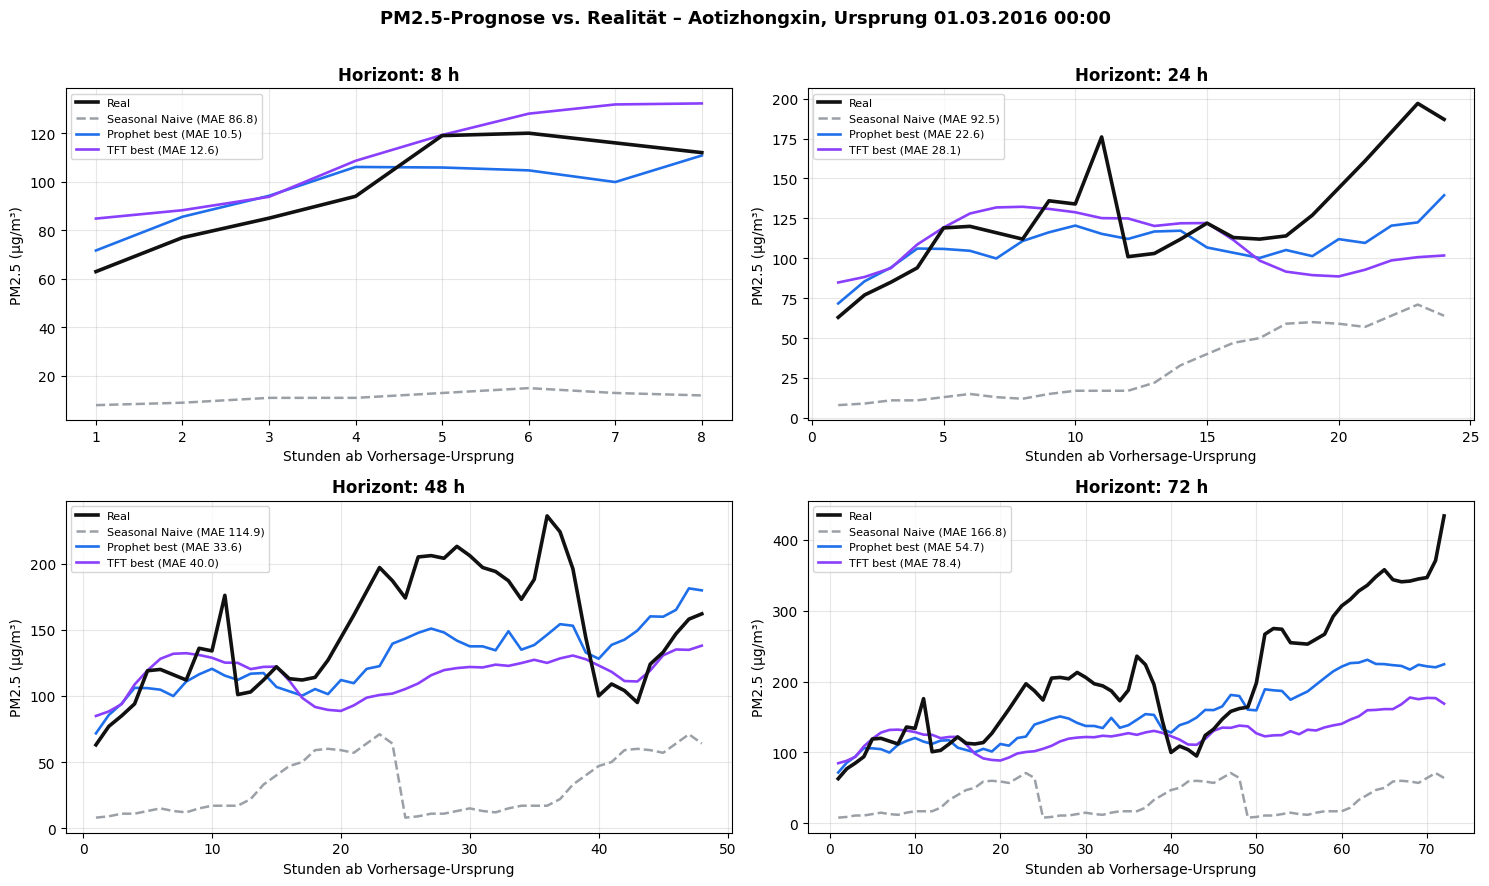

Grafiken gespeichert in C:\Users\kaiws\Claude\Projects\Business Prognosis\capstone projekt\grafiken


In [6]:
# --- Vier Panels: 8 / 24 / 48 / 72 h ---
stunden = np.arange(1, H+1)
C = {'real':'#111111','naive':'#9aa0a6','prophet':'#1f6feb','tft':'#8a3ffc'}
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, hh in zip(axes.ravel(), [8,24,48,72]):
    x = stunden[:hh]
    ax.plot(x, y_real[:hh],    color=C['real'],    lw=2.6, label='Real', zorder=5)
    ax.plot(x, y_naive[:hh],   color=C['naive'],   lw=1.8, ls='--', label=f"Seasonal Naive (MAE {mae(y_real[:hh],y_naive[:hh]):.1f})")
    ax.plot(x, y_prophet[:hh], color=C['prophet'], lw=1.9, label=f"Prophet best (MAE {mae(y_real[:hh],y_prophet[:hh]):.1f})")
    ax.plot(x, y_tft[:hh],     color=C['tft'],     lw=1.9, label=f"TFT best (MAE {mae(y_real[:hh],y_tft[:hh]):.1f})")
    ax.set_title(f'Horizont: {hh} h', fontweight='bold')
    ax.set_xlabel('Stunden ab Vorhersage-Ursprung'); ax.set_ylabel('PM2.5 (µg/m³)')
    ax.grid(alpha=.3); ax.legend(loc='best', fontsize=8)
fig.suptitle(f'PM2.5-Prognose vs. Realität – {STATION}, Ursprung {pd.Timestamp(ds_zukunft.iloc[0]):%d.%m.%Y %H:%M}',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.97])
fig.savefig(GRAF_DIR/'vergleich_8_24_48_72.png', dpi=140, bbox_inches='tight')
plt.show()
# einzelne PNGs
for hh in [8,24,48,72]:
    x=stunden[:hh]; f,a=plt.subplots(figsize=(8,4.5))
    a.plot(x,y_real[:hh],color=C['real'],lw=2.6,label='Real',zorder=5)
    a.plot(x,y_naive[:hh],color=C['naive'],lw=1.8,ls='--',label=f'Seasonal Naive (MAE {mae(y_real[:hh],y_naive[:hh]):.1f})')
    a.plot(x,y_prophet[:hh],color=C['prophet'],lw=1.9,label=f'Prophet best (MAE {mae(y_real[:hh],y_prophet[:hh]):.1f})')
    a.plot(x,y_tft[:hh],color=C['tft'],lw=1.9,label=f'TFT best (MAE {mae(y_real[:hh],y_tft[:hh]):.1f})')
    a.set_title(f'{STATION} – Horizont {hh} h',fontweight='bold'); a.set_xlabel('Stunden ab Ursprung'); a.set_ylabel('PM2.5 (µg/m³)')
    a.grid(alpha=.3); a.legend(loc='best',fontsize=8); f.tight_layout()
    f.savefig(GRAF_DIR/f'vergleich_{hh}h.png', dpi=140, bbox_inches='tight'); plt.close(f)
print('Grafiken gespeichert in', GRAF_DIR.resolve())

### Hinweise
- **Ein Ursprung, Perfect Prognosis:** Prophet und TFT kennen hier das echte Zukunftswetter (fairer Vergleich der besten Ansätze). Für den realistischen Fall die Lag-Varianten (Notebook 14) nutzen.
- **Anderes Fenster zeigen:** `STARTOFFSET` in Zelle 2 erhöhen (in Stunden). Bei genutztem Prophet-Fallback 15b mit **gleichem** `STARTOFFSET` laufen lassen.
- **CUDA-OOM:** `WINDOWS_BATCH`/`HIDDEN_SIZE` senken, danach Kernel neu starten.